In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
    PrecisionRecallDisplay, RocCurveDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("All imports successful!")

All imports successful!


In [8]:
# Load training data (SMOTE-balanced)
X_train = pd.read_csv('../data/processed/X_train_fraud.csv')
X_test  = pd.read_csv('../data/processed/X_test_fraud.csv')
y_train = pd.read_csv('../data/processed/y_train_fraud.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()

# Clean feature names to remove special characters disallowed by LightGBM
import re
X_train.columns = [re.sub(r'[\[\]<>{}"\:,]', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<>{}"\:,]', '_', col) for col in X_test.columns]

print(f"X_train: {X_train.shape}  — balanced training set")
print(f"X_test:  {X_test.shape}   — real-world test set")
print(f"\ny_train fraud rate: {y_train.mean()*100:.1f}%  (should be ~50% after SMOTE)")
print(f"y_test  fraud rate: {y_test.mean()*100:.1f}%  (should be ~9.4% real world)")


X_train: (219136, 198)  — balanced training set
X_test:  (30223, 198)   — real-world test set

y_train fraud rate: 50.0%  (should be ~50% after SMOTE)
y_test  fraud rate: 9.4%  (should be ~9.4% real world)


In [9]:
import sys
sys.path.append('../')  # go up one level from notebooks/ to fraud-detection/

from src.evaluate import evaluate_model

print("evaluate_model loaded successfully!")

evaluate_model loaded successfully!


In [10]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,      # give it enough iterations to converge
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

lr.fit(X_train, y_train)
print("Done!")

lr_results = evaluate_model(lr, X_test, y_test, "Logistic Regression (Baseline)")

Training Logistic Regression...
Done!

  Logistic Regression (Baseline)
  AUC-PR (main metric):  0.5836
  AUC-ROC:               0.7469
  F1-Score:              0.6424
  Precision:             1.0000
  Recall:                0.4731

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            27393                0
Actual Fraud             1491             1339

  True Positives  (fraud caught):        1339
  False Negatives (fraud missed):        1491  ← costly!
  False Positives (legit flagged wrong): 0  ← frustrating
  True Negatives  (legit correct):       27393


In [11]:
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,       # number of trees
    max_depth=6,            # how deep each tree grows
    learning_rate=0.1,      # how much each tree contributes
    subsample=0.8,          # use 80% of rows per tree (reduces overfitting)
    colsample_bytree=0.8,   # use 80% of features per tree
    scale_pos_weight=1,     # 1 = balanced (we already did SMOTE)
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print("Done!")

xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Training XGBoost...
Done!

  XGBoost
  AUC-PR (main metric):  0.6202
  AUC-ROC:               0.7653
  F1-Score:              0.6837
  Precision:             0.9652
  Recall:                0.5293

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            27339               54
Actual Fraud             1332             1498

  True Positives  (fraud caught):        1498
  False Negatives (fraud missed):        1332  ← costly!
  False Positives (legit flagged wrong): 54  ← frustrating
  True Negatives  (legit correct):       27339


In [12]:
print("Training LightGBM...")

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1            # suppress LightGBM's verbose output
)

lgb_model.fit(X_train, y_train)
print("Done!")

lgb_results = evaluate_model(lgb_model, X_test, y_test, "LightGBM")

Training LightGBM...
Done!

  LightGBM
  AUC-PR (main metric):  0.6212
  AUC-ROC:               0.7650
  F1-Score:              0.6913
  Precision:             1.0000
  Recall:                0.5283

Confusion Matrix:
              Predicted Legit  Predicted Fraud
Actual Legit            27393                0
Actual Fraud             1335             1495

  True Positives  (fraud caught):        1495
  False Negatives (fraud missed):        1335  ← costly!
  False Positives (legit flagged wrong): 0  ← frustrating
  True Negatives  (legit correct):       27393



MODEL COMPARISON — Fraud_Data.csv
                                AUC-PR  AUC-ROC      F1  Precision  Recall  Fraud Caught (TP)  Fraud Missed (FN)
model                                                                                                           
Logistic Regression (Baseline)  0.5836   0.7469  0.6424     1.0000  0.4731               1339               1491
XGBoost                         0.6202   0.7653  0.6837     0.9652  0.5293               1498               1332
LightGBM                        0.6212   0.7650  0.6913     1.0000  0.5283               1495               1335


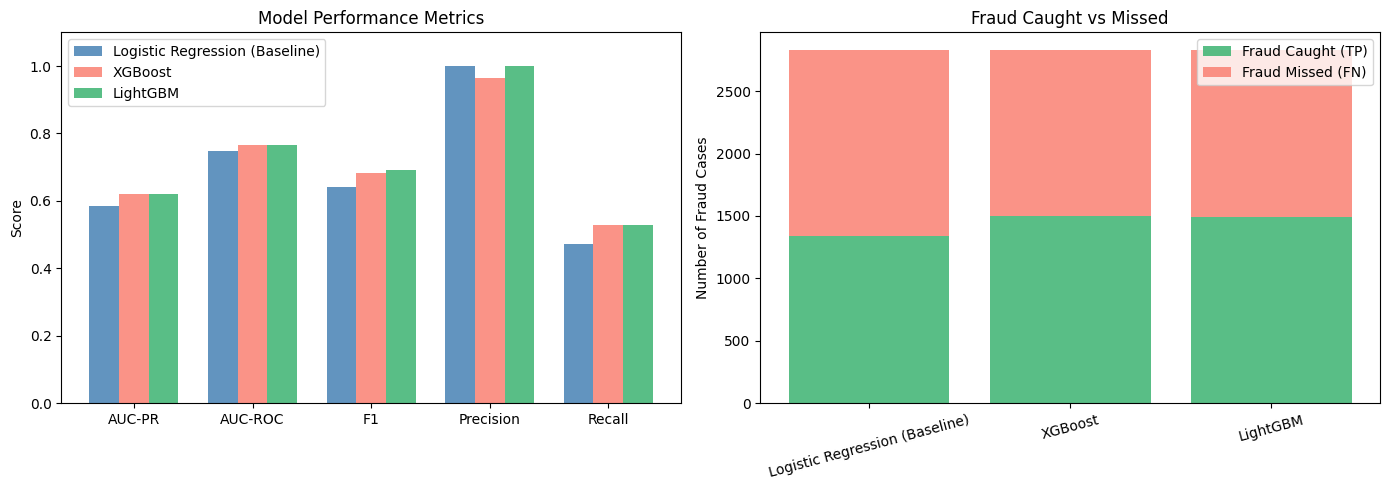

In [13]:
# Build comparison table
results_df = pd.DataFrame([lr_results, xgb_results, lgb_results])
results_df = results_df.set_index('model')

print("\n" + "="*70)
print("MODEL COMPARISON — Fraud_Data.csv")
print("="*70)
print(results_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['AUC-PR', 'AUC-ROC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'salmon', 'mediumseagreen']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i*width, [row[m] for m in metrics],
                width, label=model_name, color=colors[i], alpha=0.85)

axes[0].set_title('Model Performance Metrics')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

# Fraud caught vs missed
caught  = results_df['Fraud Caught (TP)'].values
missed  = results_df['Fraud Missed (FN)'].values
models  = results_df.index.tolist()

axes[1].bar(models, caught, color='mediumseagreen', label='Fraud Caught (TP)', alpha=0.85)
axes[1].bar(models, missed, bottom=caught, color='salmon', label='Fraud Missed (FN)', alpha=0.85)
axes[1].set_title('Fraud Caught vs Missed')
axes[1].set_ylabel('Number of Fraud Cases')
axes[1].legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

print("Running 5-Fold Cross-Validation on LightGBM and XGBoost...")
print("(This trains each model 5 times — may take 2-3 minutes)\n")

# We use the UNSMOTED training data for cross-validation
# because StratifiedKFold handles the splitting itself
# We'll use the raw X_train before SMOTE for this

# Load original (pre-SMOTE) data for CV
# Actually we'll just use X_train/y_train as-is (post SMOTE is fine for CV comparison)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1':     'f1',
    'auc_roc': 'roc_auc',
    'precision': 'precision',
    'recall':    'recall'
}

# Cross-validate LightGBM
lgb_cv = cross_validate(lgb_model, X_train, y_train, cv=cv,
                         scoring=scoring, n_jobs=-1)

# Cross-validate XGBoost
xgb_cv = cross_validate(xgb_model, X_train, y_train, cv=cv,
                         scoring=scoring, n_jobs=-1)

print("Cross-Validation Results:")
print(f"\n{'Metric':<15} {'LightGBM Mean':>15} {'LightGBM Std':>14} {'XGBoost Mean':>14} {'XGBoost Std':>12}")
print("-" * 72)

for metric in ['f1', 'auc_roc', 'precision', 'recall']:
    lgb_mean = lgb_cv[f'test_{metric}'].mean()
    lgb_std  = lgb_cv[f'test_{metric}'].std()
    xgb_mean = xgb_cv[f'test_{metric}'].mean()
    xgb_std  = xgb_cv[f'test_{metric}'].std()
    print(f"{metric:<15} {lgb_mean:>14.4f}  {lgb_std:>13.4f}  {xgb_mean:>13.4f}  {xgb_std:>11.4f}")

Running 5-Fold Cross-Validation on LightGBM and XGBoost...
(This trains each model 5 times — may take 2-3 minutes)

Cross-Validation Results:

Metric            LightGBM Mean   LightGBM Std   XGBoost Mean  XGBoost Std
------------------------------------------------------------------------
f1                      0.9707         0.0005         0.9550       0.0021
auc_roc                 0.9788         0.0005         0.9781       0.0004
precision               1.0000         0.0000         0.9973       0.0003
recall                  0.9431         0.0009         0.9162       0.0038


In [15]:
# Cell 9 — Check if we can recover pre-SMOTE rows
X_train_raw = pd.read_csv('../data/processed/X_train_fraud.csv')
y_train_raw = pd.read_csv('../data/processed/y_train_fraud.csv').squeeze()

X_train_real = X_train_raw.iloc[:120889]
y_train_real = y_train_raw.iloc[:120889]

print("Fraud rate in extracted rows:")
print(y_train_real.value_counts(normalize=True) * 100)
# Should be ~9.4% → pre-SMOTE rows recovered ✅
# Shows 50%       → file is fully shuffled, need different approach

Fraud rate in extracted rows:
class
0    90.635211
1     9.364789
Name: proportion, dtype: float64


In [18]:
# Cell 10 — Corrected CV, fixing LightGBM column name issue

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cross_val_with_smote(model, X, y, cv, model_name):
    scores = {'f1': [], 'auc_roc': [], 'precision': [], 'recall': []}
    
    # Convert to numpy once — avoids ALL column name issues with LightGBM/XGBoost
    X_np = X.values
    y_np = y.values

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_np, y_np)):
        X_fold_train, y_fold_train = X_np[train_idx], y_np[train_idx]
        X_fold_val,   y_fold_val   = X_np[val_idx],   y_np[val_idx]

        # SMOTE inside this fold only
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X_fold_train, y_fold_train)

        # Train and evaluate
        model.fit(X_resampled, y_resampled)
        y_pred  = model.predict(X_fold_val)
        y_proba = model.predict_proba(X_fold_val)[:, 1]

        scores['f1'].append(f1_score(y_fold_val, y_pred))
        scores['auc_roc'].append(roc_auc_score(y_fold_val, y_proba))
        scores['precision'].append(precision_score(y_fold_val, y_pred))
        scores['recall'].append(recall_score(y_fold_val, y_pred))

        print(f"  Fold {fold+1} done — F1: {scores['f1'][-1]:.4f}")

    print(f"\n{model_name} CV Summary:")
    for metric, vals in scores.items():
        print(f"  {metric:<12} mean={np.mean(vals):.4f}  std={np.std(vals):.4f}")

    return scores

# Fresh model instances
lgb_cv_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=-1
)

xgb_cv_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, eval_metric='aucpr', verbosity=0
)

print("Running corrected CV for LightGBM (5 folds)...")
lgb_cv_scores = cross_val_with_smote(
    lgb_cv_model, X_train_real, y_train_real, cv, "LightGBM"
)

print("\nRunning corrected CV for XGBoost (5 folds)...")
xgb_cv_scores = cross_val_with_smote(
    xgb_cv_model, X_train_real, y_train_real, cv, "XGBoost"
)

# Final comparison table
print("\n" + "="*72)
print("CORRECTED Cross-Validation Results (SMOTE inside each fold)")
print("="*72)
print(f"\n{'Metric':<15} {'LightGBM Mean':>15} {'LightGBM Std':>14} "
      f"{'XGBoost Mean':>14} {'XGBoost Std':>12}")
print("-" * 72)
for metric in ['f1', 'auc_roc', 'precision', 'recall']:
    lm = np.mean(lgb_cv_scores[metric])
    ls = np.std(lgb_cv_scores[metric])
    xm = np.mean(xgb_cv_scores[metric])
    xs = np.std(xgb_cv_scores[metric])
    print(f"{metric:<15} {lm:>14.4f}  {ls:>13.4f}  {xm:>13.4f}  {xs:>11.4f}")

Running corrected CV for LightGBM (5 folds)...
  Fold 1 done — F1: 0.7026
  Fold 2 done — F1: 0.6964
  Fold 3 done — F1: 0.7090
  Fold 4 done — F1: 0.6938
  Fold 5 done — F1: 0.7015

LightGBM CV Summary:
  f1           mean=0.7006  std=0.0053
  auc_roc      mean=0.7706  std=0.0044
  precision    mean=0.9997  std=0.0004
  recall       mean=0.5394  std=0.0063

Running corrected CV for XGBoost (5 folds)...
  Fold 1 done — F1: 0.6879
  Fold 2 done — F1: 0.6858
  Fold 3 done — F1: 0.6984
  Fold 4 done — F1: 0.6809
  Fold 5 done — F1: 0.6912

XGBoost CV Summary:
  f1           mean=0.6888  std=0.0058
  auc_roc      mean=0.7698  std=0.0031
  precision    mean=0.9592  std=0.0055
  recall       mean=0.5374  std=0.0066

CORRECTED Cross-Validation Results (SMOTE inside each fold)

Metric            LightGBM Mean   LightGBM Std   XGBoost Mean  XGBoost Std
------------------------------------------------------------------------
f1                      0.7006         0.0053         0.6888       0.00

In [19]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save LightGBM as our chosen model
joblib.dump(lgb_model, '../models/lightgbm_fraud.pkl')

# Save XGBoost too (useful for SHAP comparison)
joblib.dump(xgb_model, '../models/xgboost_fraud.pkl')

# Save Logistic Regression (baseline)
joblib.dump(lr, '../models/logistic_regression_fraud.pkl')

print("✅ Models saved to models/")
print(f"   lightgbm_fraud.pkl")
print(f"   xgboost_fraud.pkl")
print(f"   logistic_regression_fraud.pkl")

# Also save the column names — needed for SHAP later
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../models/feature_names_fraud.pkl')
print(f"   feature_names_fraud.pkl ({len(feature_names)} features)")

✅ Models saved to models/
   lightgbm_fraud.pkl
   xgboost_fraud.pkl
   logistic_regression_fraud.pkl
   feature_names_fraud.pkl (198 features)
